# Benchmarki

# Symulowana Bifurkacja


In [14]:
# Obliczenia potrzebne do benchmarku

import os
import time
import pickle

import cupy as cp
import matplotlib.pyplot as plt
import numpy as np

from funkcje_pomocnicze import read_instance, instance
from benchmarks import discrete_simulated_bifurcation_gpu, discrete_simulated_bifurcation, discrete_simulated_bifurcation_gpu_naive
from IPython.utils.io import capture_output
from tqdm import tqdm

P2 = instance(os.path.join("instancje", "Pegasus", "P2_CBFM-P.txt"), -39.0)
P4 = instance(os.path.join("instancje", "Pegasus", "P4_CBFM-P.txt"), -469.0)
P8 = instance(os.path.join("instancje", "Pegasus", "P8_CBFM-P.txt"), -2752.0)
P12 = instance(os.path.join("instancje", "Pegasus", "P12_CBFM-P.txt"), -6831.0)
P16 = instance(os.path.join("instancje", "Pegasus", "P16_CBFM-P.txt"), -12772.0)  



functions = [discrete_simulated_bifurcation_gpu]
pegasus= [P2, P4, P8, P12, P16]
zephyr = []

global_results = []
for function in functions:
    gaps = []
    times = []
    for instance in tqdm(pegasus):
        J, h = read_instance(instance.path, convention="minus_half")
        J2 = cp.asarray(J, dtype=cp.float32)
        h2 = cp.asarray(h, dtype=cp.float32)
        # kompilacja 
        with capture_output() as captured:
            states, energies = function(J2, h2, 100, 0.25, 2**5)

        result = 0
        elapsed = 0
        count = 0
        best_result = 0
        start = time.time()
        while result != instance.best_energy :
            with capture_output() as captured:
                states, energies = function(J2, h2, 1000 * (1 + count), 0.5, 2**(10 + max(count, 5)), c_0_scaling=0.7)
            result = min(energies).item()
            
            if result < best_result:
                best_result = result

            checkpoint = time.time()
            elapsed = checkpoint - start
            gap = (instance.best_energy - best_result)/instance.best_energy

            if elapsed >= 60:
                if gap < 0.01:
                    break
            count += 1
                
        gaps.append((instance.best_energy - best_result)/instance.best_energy)    
        print(gaps)  
        times.append(elapsed)
        print(times)


with open(os.path.join("wyniki", "sbm_pegasus_results.pkl"), "wb") as f:
    data = (times, gaps)
    pickle.dump(data, f)



 20%|██        | 1/5 [00:12<00:48, 12.23s/it]

[-0.0]
[1.1795628070831299]


 40%|████      | 2/5 [00:15<00:20,  6.72s/it]

[-0.0, -0.0]
[1.1795628070831299, 2.8318285942077637]


 60%|██████    | 3/5 [00:31<00:22, 11.15s/it]

[-0.0, -0.0, -0.0]
[1.1795628070831299, 2.8318285942077637, 16.154260873794556]


 80%|████████  | 4/5 [01:33<00:31, 31.15s/it]

[-0.0, -0.0, -0.0, 0.0020494803103498754]
[1.1795628070831299, 2.8318285942077637, 16.154260873794556, 60.367833614349365]


100%|██████████| 5/5 [04:34<00:00, 54.80s/it]

[-0.0, -0.0, -0.0, 0.0020494803103498754, 0.003601628562480426]
[1.1795628070831299, 2.8318285942077637, 16.154260873794556, 60.367833614349365, 175.9983320236206]


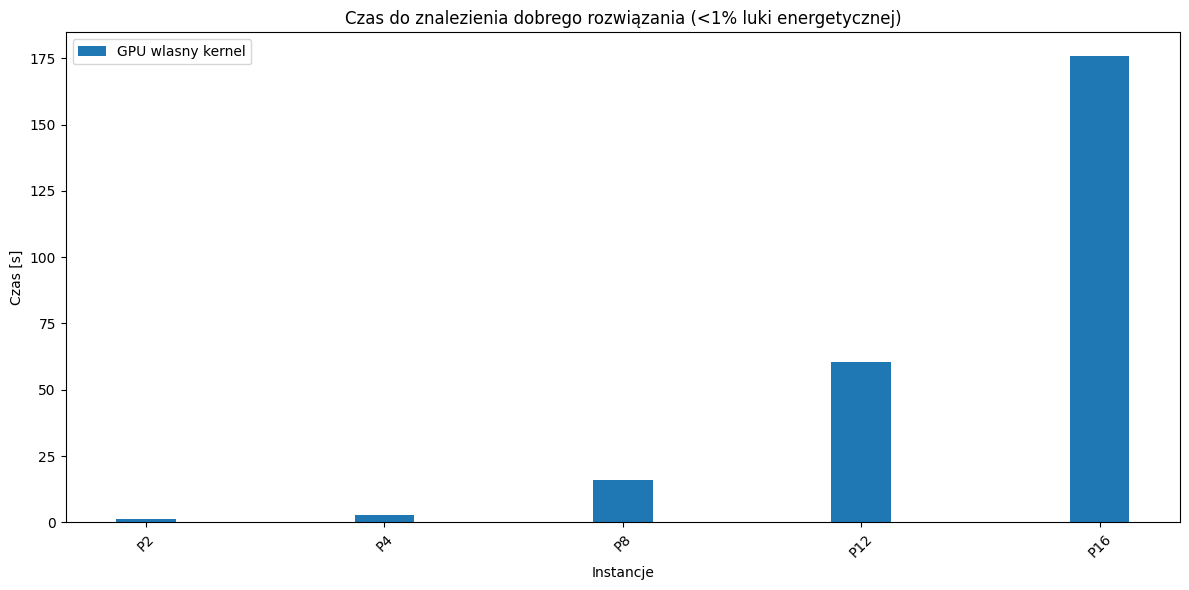

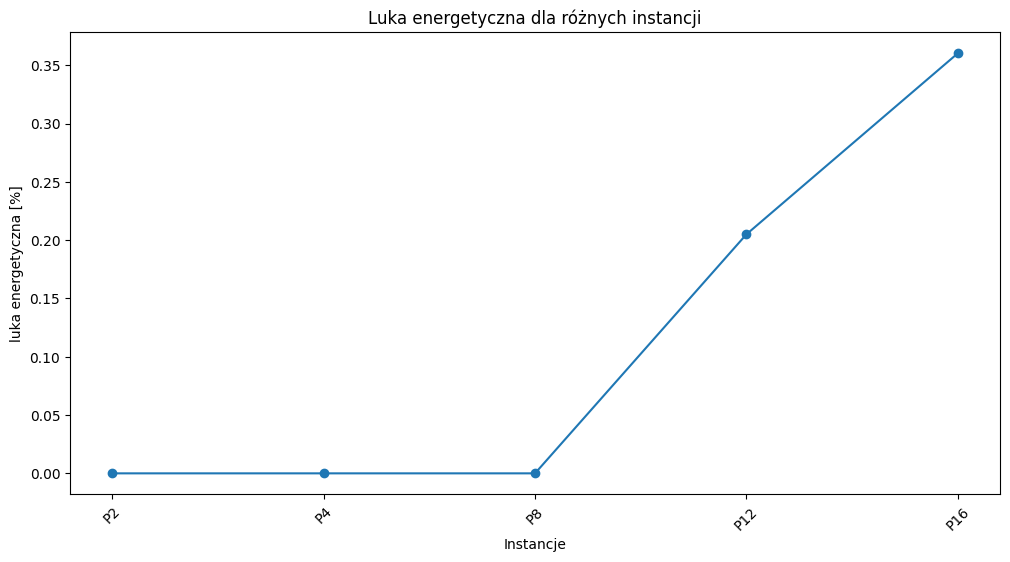

In [22]:
# Rysowanie wykresów

import os
import pickle

import matplotlib.pyplot as plt
import numpy as np


with open(os.path.join("wyniki", "sbm_pegasus_results.pkl"), "rb") as f:
    times, gaps = pickle.load(f)


instancje = ["P2", "P4", "P8", "P12", "P16"]

x = np.arange(len(instancje))
width = 0.25  

fig, ax = plt.subplots(figsize=(12, 6))

#rects2 = ax.bar(x, global_results[1], width, label='GPU naiwne')
rects3 = ax.bar(x, times, width, label='GPU wlasny kernel')

ax.set_xlabel("Instancje")
ax.set_ylabel("Czas [s]")
ax.set_title(r"Czas do znalezienia dobrego rozwiązania (<1% luki energetycznej)")
ax.set_xticks(x)
ax.set_xticklabels(instancje, rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(12, 6))

gaps_procent = [x * 100 for x in gaps]
ax2.plot(x, gaps_procent, label='GPU wlasny kernel', marker='o', linestyle='-')
ax2.set_xlabel("Instancje")
ax2.set_ylabel("luka energetyczna [%]")
ax2.set_title("Luka energetyczna dla różnych instancji")
ax2.set_xticks(x)
ax2.set_xticklabels(instancje, rotation=45)
plt.show()

In [ ]:
import torch
import simulated_bifurcation as sb
import numpy as np
from funkcje_pomocnicze import read_instance, pegasus_benchmark, test_pegasus, ising_to_qubo, small_pegasus
from benchmarks import discrete_simulated_bifurcation

J, h = read_instance(small_pegasus.path, convention="minus_half")
J1, h1 = read_instance(small_pegasus.path, convention="dwave")

def to_sym_matrix(M: np.ndarray):
    sym_matrix = np.zeros(M.size)
    for i in range(M.size[0]):
        for j in range(M.size[1]):
            a_ij = M[i, j]
            sym_matrix[i, j] = a_ij
            sym_matrix[j, i] = a_ij
    return sym_matrix

J1 = torch.tensor(to_sym_matrix(J1), dtype=torch.float32)
h1 = torch.tensor(h1, dtype=torch.float32)




states, energies = discrete_simulated_bifurcation(J, h, 200, 0.25, 2**9)
print(min(energies))
sb.minimize(J1, h1, domain="spin", dtype=torch.float32)

Symulowana Bifurkacja: 100%|██████████| 200/200 [00:01<00:00, 120.10it/s]


-39.0


🏁 Bifurcated agents: 100%|██████████| 128/128 [00:00<00:00, 455.58 agents/s]


(tensor([-1., -1., -1., -1.,  1.,  1.,  1.,  1.,  1., -1., -1., -1.,  1., -1.,
          1.,  1., -1.,  1.,  1.,  1.,  1.,  1., -1.,  1.]),
 tensor(-33.))

## Implementacja GPU

In [ ]:
import torch
import simulated_bifurcation as sb
import cupy as cp
from funkcje_pomocnicze import read_instance,  pegasus_benchmark
from benchmarks import discrete_simulated_bifurcation_gpu
from IPython.utils.io import capture_output

for instance in pegasus_benchmark:
    J, h = read_instance(instance.path, convention="minus_half")
    J2 = cp.asarray(J, dtype=cp.float32)
    h2 = cp.asarray(h, dtype=cp.float32)
    
    with capture_output() as captured:
        states, energies = discrete_simulated_bifurcation_gpu(J2, h2, 1000, 0.25, 2**11)

    print(min(energies))
    print(instance.best_energy)

# Brute Force

In [4]:
##############################
# Uruchom tą komurkę z kernelem "bruteforce"
##############################
import time
import os
import pickle
import numpy as np
from dimod import BinaryQuadraticModel
from tqdm import tqdm
from omnisolver.bruteforce.gpu.sampler import BruteforceGPUSampler

sampler = BruteforceGPUSampler()
suffix_size = 10
threadsperblock = 256
blockspergrid = 2**(suffix_size)//threadsperblock

# Kompilacja
Q = np.random.uniform(-1, 1, size=(10, 10))
Q = np.triu(Q)
bqm = BinaryQuadraticModel(Q, vartype="BINARY")
sampler.sample(bqm, num_states=10, suffix_size=10, grid_size=blockspergrid, 
                   block_size=threadsperblock, dtype=np.float32)

times = []
for n in tqdm(range(10, 33)):
    Q = np.random.uniform(-1, 1, size=(n, n))
    Q = np.triu(Q)
    bqm = BinaryQuadraticModel(Q, vartype="BINARY")
    start = time.time()
    sampler.sample(bqm, num_states=10, suffix_size=10, grid_size=blockspergrid, 
                   block_size=threadsperblock, dtype=np.float32)
    end = time.time()
    times.append(end - start)

with open(os.path.join("wyniki", "omnisolver_bruteforce_results.pkl"), "wb") as f:
    pickle.dump(times, f)


100%|██████████| 23/23 [15:16<00:00, 39.84s/it] 


In [9]:
import time
import os
import pickle
import cupy as cp

from benchmarks import brute_force_gpu
from tqdm import tqdm
from IPython.utils.io import capture_output

# Kompilacja
Q = cp.random.uniform(-1, 1, size=(10, 10), dtype=cp.float32)
Q = cp.triu(Q)
brute_force_gpu(Q, 10)

times = []
for n in tqdm(range(10, 30)):
    Q = cp.random.uniform(-1, 1, size=(n, n), dtype=cp.float32)
    Q = cp.triu(Q)
    start = time.time()
    with capture_output() as captured:
        brute_force_gpu(Q, num_states=10, sweep_size_exponent=10)
    end = time.time()
    times.append(end - start)

with open(os.path.join("wyniki", "bruteforce_results.pkl"), "wb") as f:
    pickle.dump(times, f)

100%|██████████| 20/20 [16:57<00:00, 50.90s/it] 


In [ ]:
import time
import os
import pickle
import numpy as np

from benchmarks import brute_force_naive
from tqdm import tqdm
from IPython.utils.io import capture_output


times = []
n_range = list(range(10, 27))
for n in tqdm(n_range, desc="Wyczerpujące przeszukiwanie dla różnych n"):

    J = np.triu(np.random.uniform(-1, 1, size=(n, n)), k=1)  # losowa gęsta macierz górnotrójkątna
    h = np.random.uniform(-1, 1, size=n)  # losowy wektor
    start = time.time()
    with capture_output() as captured:
        state, energy = brute_force_naive(J, h)
    end = time.time()
    elapsed = end - start
    times.append(elapsed)

with open(os.path.join("wyniki", "bruteforce_cpu_results.pkl"), "wb") as f:
    pickle.dump(times, f)

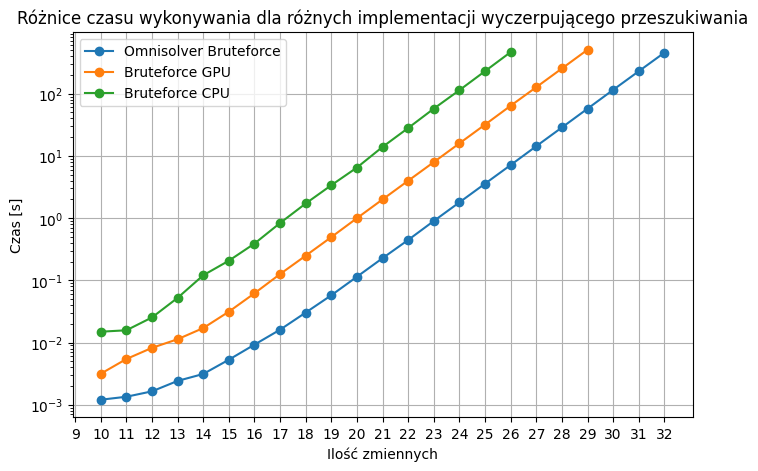

In [14]:
import pickle
import matplotlib.pyplot as plt

with open(os.path.join("wyniki", "bruteforce_results.pkl"), "rb") as f:
    times_bf = pickle.load(f)

with open(os.path.join("wyniki", "omnisolver_bruteforce_results.pkl"), "rb") as f:
    times_omnisolver = pickle.load(f)

with open(os.path.join("wyniki", "bruteforce_cpu_results.pkl"), "rb") as f:
    times_bf_cpu = pickle.load(f)

x1 = list(range(10, 33))
x2 = list(range(10, 30))
x3 = list(range(10, 27))

plt.figure(figsize=(8, 5))
plt.plot(x1, times_omnisolver, label='Omnisolver Bruteforce', marker='o', linestyle='-')
plt.plot(x2, times_bf, label='Bruteforce GPU', marker='o', linestyle='-')
plt.plot(x3, times_bf_cpu, label='Bruteforce CPU', marker='o', linestyle='-')
plt.xticks([9] + list(range(10, 33)))
plt.yscale('log', base=10)
plt.xlabel('Ilość zmiennych')
plt.ylabel('Czas [s]')
plt.title('Różnice czasu wykonywania dla różnych implementacji wyczerpującego przeszukiwania')
plt.legend()
plt.grid(True)
plt.show()